In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# ARIMA-Based Burst Detection
# Idea sketch for burst gravitational-wave searches

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/ja/user_guide/tutorials/case_arima_burst_search.ipynb)

## Introduction
Detector data are dominated by approximately stationary background noise, while burst gravitational waves (for example from core-collapse supernovae) appear as short, non-stationary transients embedded in that noise.

This notebook demonstrates the idea of using an **autoregressive model (ARIMA)** to learn the stationary background and make burst-like residuals stand out. It is a simple example of an unmodeled search strategy that does not rely on waveform templates.

### References
- Autoregressive Search of Gravitational Waves: Denoising (ARIMA_DeNoise.pdf)
- BEACON: Autoregressive Search for Unmodeled transients (BEACON.pdf)
- Sparkler: Autoregressive Search of Unmodeled GW (Sparkler_1min.pdf)


In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    import matplotlib.pyplot as plt
    import numpy as np
    import sklearn.utils.validation

    # Monkeypatch for pmdarima compatibility with scikit-learn >= 1.6
    _orig_check_array = sklearn.utils.validation.check_array

    def _patched_check_array(*args, **kwargs):
        kwargs.pop("force_all_finite", None)
        return _orig_check_array(*args, **kwargs)

    sklearn.utils.validation.check_array = _patched_check_array

    warnings.filterwarnings(
        "ignore", message=r".*force_all_finite.*", category=FutureWarning
    )
    warnings.filterwarnings("ignore", category=FutureWarning, module=r"sklearn\..*")
    warnings.filterwarnings("ignore", category=FutureWarning, module=r"pmdarima\..*")

    from gwexpy.timeseries import TimeSeries
    from gwexpy.noise.wave import gaussian, sine, from_asd, colored


## 1. Generate detector noise
First we simulate detector background noise. When available we use an aLIGO design-sensitivity model; otherwise we fall back to generic colored noise.


In [ ]:
# === Parameters ===
sample_rate = 4096  # Hz
duration     = 16   # seconds
seed         = 42

# === Noise generation ===
try:
    from gwexpy.noise.gwinc_ import from_pygwinc
    # Get aLIGO sensitivity curve
    asd = from_pygwinc("aLIGO", fmin=10.0, fmax=sample_rate/2, df=1.0/duration)
    # Generate time-series noise from ASD
    noise = from_asd(asd, duration=duration, sample_rate=sample_rate, seed=seed,
                     name="aLIGO_noise")
    noise_model_name = "aLIGO (pygwinc)"
except ImportError:
    # Fallback if pygwinc is not installed: power-law colored noise (1/f)
    noise = colored(duration=duration, sample_rate=sample_rate,
                    exponent=0.5, amplitude=1e-21, seed=seed,
                    name="colored_noise")
    noise_model_name = "Colored noise (f^{-0.5})"

print(f"Noise model: {noise_model_name}")
print(f"Sample count: {len(noise)}, dt={noise.dt}s, duration={duration}s")

noise.plot()
plt.title(f"Simulated Detector Noise: {noise_model_name}")
plt.show()

## 2. Inject a burst signal
We inject a sine-Gaussian burst into the second half of the data and use it as the test segment.


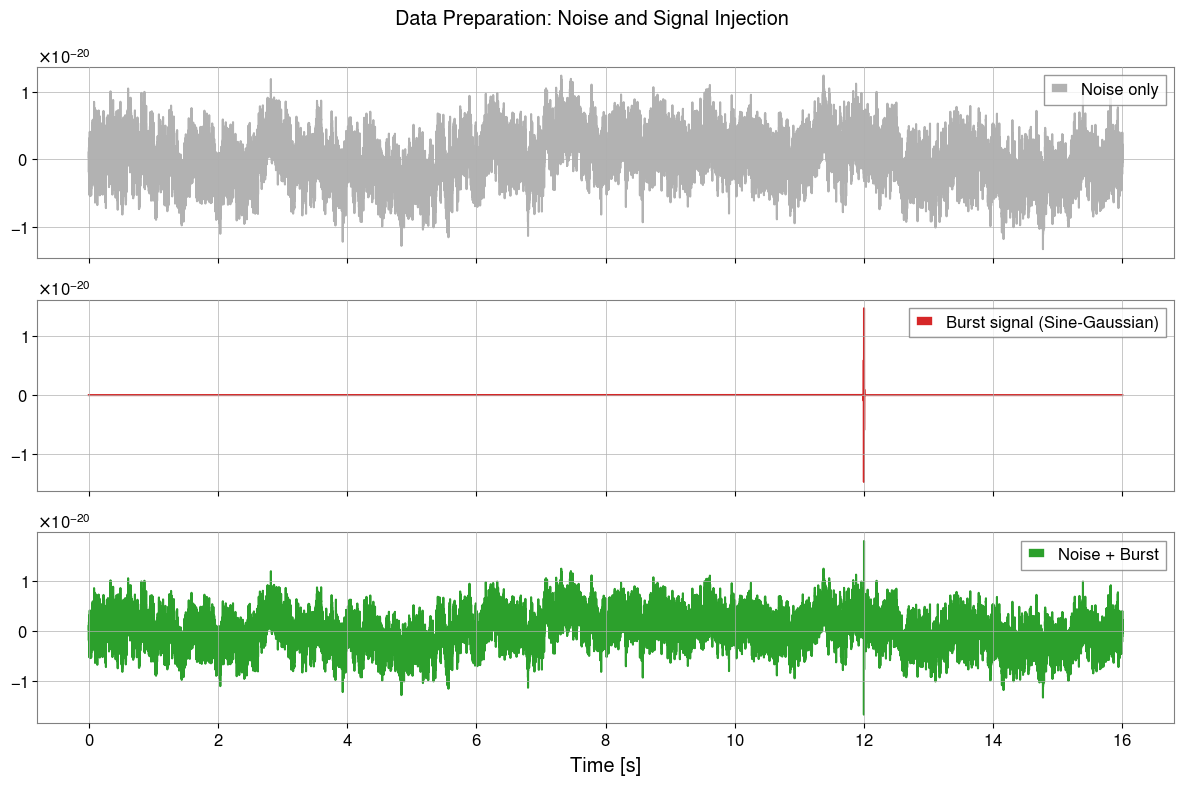

In [3]:
def make_sine_gaussian(duration, sample_rate, t_center, freq, tau, amplitude, t0=0.0):
    """Generate a Sine-Gaussian pulse"""
    t = np.arange(0, duration, 1.0/sample_rate)
    envelope = amplitude * np.exp(-((t - t_center)**2) / (2 * tau**2))
    signal = envelope * np.sin(2 * np.pi * freq * (t - t_center))
    return TimeSeries(signal, sample_rate=sample_rate, t0=t0,
                      name=f"SG_burst_f{freq}_tau{tau}")

# === Burst Signal Parameters ===
burst_time  = 12.0   # Injection time (somewhere in the last 8 seconds)
burst_freq  = 250.0  # Hz
burst_tau   = 0.002  # seconds
# Adjust amplitude so that SNR is approximately 5
std_noise = float(noise.value.std())
burst_amp   = 5.0 * std_noise

burst = make_sine_gaussian(duration, sample_rate, burst_time,
                           burst_freq, burst_tau, burst_amp)

# === Injection ===
data_with_signal = TimeSeries(
    noise.value + burst.value,
    sample_rate=sample_rate, t0=noise.t0,
    name="data_with_burst"
)

# === Visualization ===
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(noise, label="Noise only", color="gray", alpha=0.6)
axes[0].legend(loc="upper right")
axes[1].plot(burst, label="Burst signal (Sine-Gaussian)", color="tab:red")
axes[1].legend(loc="upper right")
axes[2].plot(data_with_signal, label="Noise + Burst", color="tab:green")
axes[2].legend(loc="upper right")
plt.suptitle("Data Preparation: Noise and Signal Injection")
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()


## 3. Learn the background with ARIMA
We fit an ARIMA model on the first 8 seconds, where no burst is present, so that the model captures the stationary background statistics. The data are moderately downsampled to keep the example lightweight.


In [ ]:
# === Training Data Preparation ===
# Use the first 8 seconds for the training segment
train_end_idx = int(8.0 * sample_rate)

# Downsample (4096 Hz -> 512 Hz)
downsample_factor = 8
train_data = data_with_signal[:train_end_idx:downsample_factor]

print(f"Training data: {len(train_data)} samples, Fs={train_data.sample_rate} Hz")

# fit_arima: Automatically select optimal degree with Auto-ARIMA (may take some time)
# Limited search range here for speed. Falls back to fixed order if pmdarima is not available.
try:
    result = train_data.fit_arima(auto=True, auto_kwargs={"max_p": 3, "max_q": 3, "seasonal": False})
    print("\nARIMA Fit Summary (Auto-ARIMA):")
except ImportError:
    print("\npmdarima not found. Falling back to fixed order (3, 0, 1).")
    result = train_data.fit_arima(order=(3, 0, 1), trend="c")
    print("\nARIMA Fit Summary (Fixed Order):")

print(result.summary())


## 4. Compute residuals and detect anomalies
We apply the fitted model to the remaining data and inspect the residuals. Stationary noise should leave small residuals, while an unmodeled burst produces a localized excess.


In [ ]:
# === Apply to test data ===
test_data = data_with_signal[train_end_idx::downsample_factor]

# Apply the fitted model order to compute residuals
order = result.res.model_orders
test_result = test_data.fit_arima(order=(order['ar'], 0, order['ma']), trend="c")
test_resid = test_result.residuals()

# === Threshold detection (5-sigma) ===
# Set threshold from standard deviation of training residuals
train_resid = result.residuals()
sigma = float(train_resid.value.std())
threshold = 5.0 * sigma

# Trigger detection
trigger_mask = np.abs(test_resid.value) > threshold

# === Visualization ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_resid, label="Residuals", color="gray", alpha=0.7)
ax.axhline(threshold, color="red", ls="--", label=f"Detection Threshold (5-sigma)")
ax.axhline(-threshold, color="red", ls="--")

if np.any(trigger_mask):
    t_test = test_resid.times.value
    ax.scatter(t_test[trigger_mask], test_resid.value[trigger_mask],
               color="tab:red", s=40, zorder=5, label="Trigger Detected")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("Search Results: Residuals and Triggers")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.show()

## 5. Evaluate performance versus SNR
Finally we repeat the injection for several signal-to-noise ratios to estimate how the residual-based detection responds as the burst becomes weaker.


In [ ]:
# Simple Monte Carlo evaluation
snr_values = [2, 3, 4, 5, 7, 10]
n_trials = 5
detection_rates = []

# Reuse the previously fitted model order
order_tuple = (order['ar'], 0, order['ma'])

print("Evaluating SNR sensitivity...")
for snr in snr_values:
    hits = 0
    for i in range(n_trials):
        # New noise realization
        n_val = colored(duration=4, sample_rate=sample_rate, exponent=0.5, seed=snr*100+i).value
        s_val = make_sine_gaussian(4, sample_rate, 2.0, burst_freq, burst_tau, snr * n_val.std()).value
        trial_ts = TimeSeries(n_val + s_val, sample_rate=sample_rate)[::downsample_factor]
        
        # Fit and check
        try:
            res = trial_ts.fit_arima(order=order_tuple)
            if np.any(np.abs(res.residuals().value) > 5.0 * sigma):
                hits += 1
        except:
            continue
    detection_rates.append(hits / n_trials)

plt.figure(figsize=(8, 4))
plt.plot(snr_values, detection_rates, 'o-')
plt.xlabel("Injected SNR")
plt.ylabel("Detection Rate")
plt.title("Sensitivity Curve (Approximation)")
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()

## Summary

### Key ideas behind ARIMA-based burst searches
1. **Background suppression**: model and subtract stationary noise to improve the visibility of weak transients.
2. **Residual analysis**: monitor deviations from the expected residual distribution to identify unmodeled events.

Production pipelines such as BEACON extend this idea to multiple channels and coherence checks, but this notebook captures the core intuition in a compact example.
